# Carregando dados e imports

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


with open('../data/raw/survey_responses.json', 'r', encoding="utf-8") as f:
    data = json.load(f)

print(f"Quantidade de respostas: {len(data)}")

Quantidade de respostas: 22


# Adicionando variáveis de soma de conhecimento prévio e de resposta da pesquisa

In [2]:
for user in data:
    pre_research = user.get("preResearch", [])
    user["preResearchSum"] = sum(
        int(item.get("answer", 0))
        for item in pre_research
        if str(item.get("answer", "")).isdigit()
    )

    research = user.get("research", [])
    user["shapGlobalSum"] = sum(
        int(item.get("answer", 0))
        for item in research
        if str(item.get("answer", "")).isdigit() and "fig1" in item.get("questionId", "")
    )
    user["shapLocalSum"] = sum(
        int(item.get("answer", 0))
        for item in research
        if str(item.get("answer", "")).isdigit() and "fig2" in item.get("questionId", "")
    )

# Alfa de Cronbach para os questionários de conhecimento prévio e da pesquisa

In [3]:
def cronbach_alpha(df):
    items = df.shape[1]
    variances = df.var(axis=0, ddof=1)
    total_variance = df.sum(axis=1).var(ddof=1)
    alpha = (items / (items - 1)) * (1 - (variances.sum() / total_variance))
    return alpha

# Perguntas do preResearch
pre_research_data = pd.DataFrame({
    "pre-usage": [int(user["preResearch"][0]["answer"]) for user in data],
    "pre-knowledge": [int(user["preResearch"][1]["answer"]) for user in data],
    "pre-tools": [int(user["preResearch"][2]["answer"]) for user in data],
})

# Perguntas do research para figura 1
research_fig1_data = pd.DataFrame({
    "user-aware": [int(item["answer"]) for user in data for item in user["research"] if "user-aware-fig1" in item["questionId"]],
    "context-aware": [int(item["answer"]) for user in data for item in user["research"] if "context-aware-fig1" in item["questionId"]],
    "objectivity": [int(item["answer"]) for user in data for item in user["research"] if "objectivity-fig1" in item["questionId"]],
    "understandability": [int(item["answer"]) for user in data for item in user["research"] if "understandability-fig1" in item["questionId"]],
    "informative": [int(item["answer"]) for user in data for item in user["research"] if "informative-fig1" in item["questionId"]],
})

# Perguntas do research para figura 2
research_fig2_data = pd.DataFrame({
    "user-aware": [int(item["answer"]) for user in data for item in user["research"] if "user-aware-fig2" in item["questionId"]],
    "context-aware": [int(item["answer"]) for user in data for item in user["research"] if "context-aware-fig2" in item["questionId"]],
    "objectivity": [int(item["answer"]) for user in data for item in user["research"] if "objectivity-fig2" in item["questionId"]],
    "understandability": [int(item["answer"]) for user in data for item in user["research"] if "understandability-fig2" in item["questionId"]],
    "informative": [int(item["answer"]) for user in data for item in user["research"] if "informative-fig2" in item["questionId"]],
})

# Calcular o Alfa de Cronbach
pre_research_alpha = cronbach_alpha(pre_research_data)
research_fig1_alpha = cronbach_alpha(research_fig1_data)
research_fig2_alpha = cronbach_alpha(research_fig2_data)

print(f"Alfa de Cronbach para XAI: {pre_research_alpha:.3f}")
print(f"Alfa de Cronbach para SHAP (Figura 1): {research_fig1_alpha:.3f}")
print(f"Alfa de Cronbach para SHAP (Figura 2): {research_fig2_alpha:.3f}")

Alfa de Cronbach para XAI: 0.516
Alfa de Cronbach para SHAP (Figura 1): 0.951
Alfa de Cronbach para SHAP (Figura 2): 0.919


# Analisando as respostas do questionário

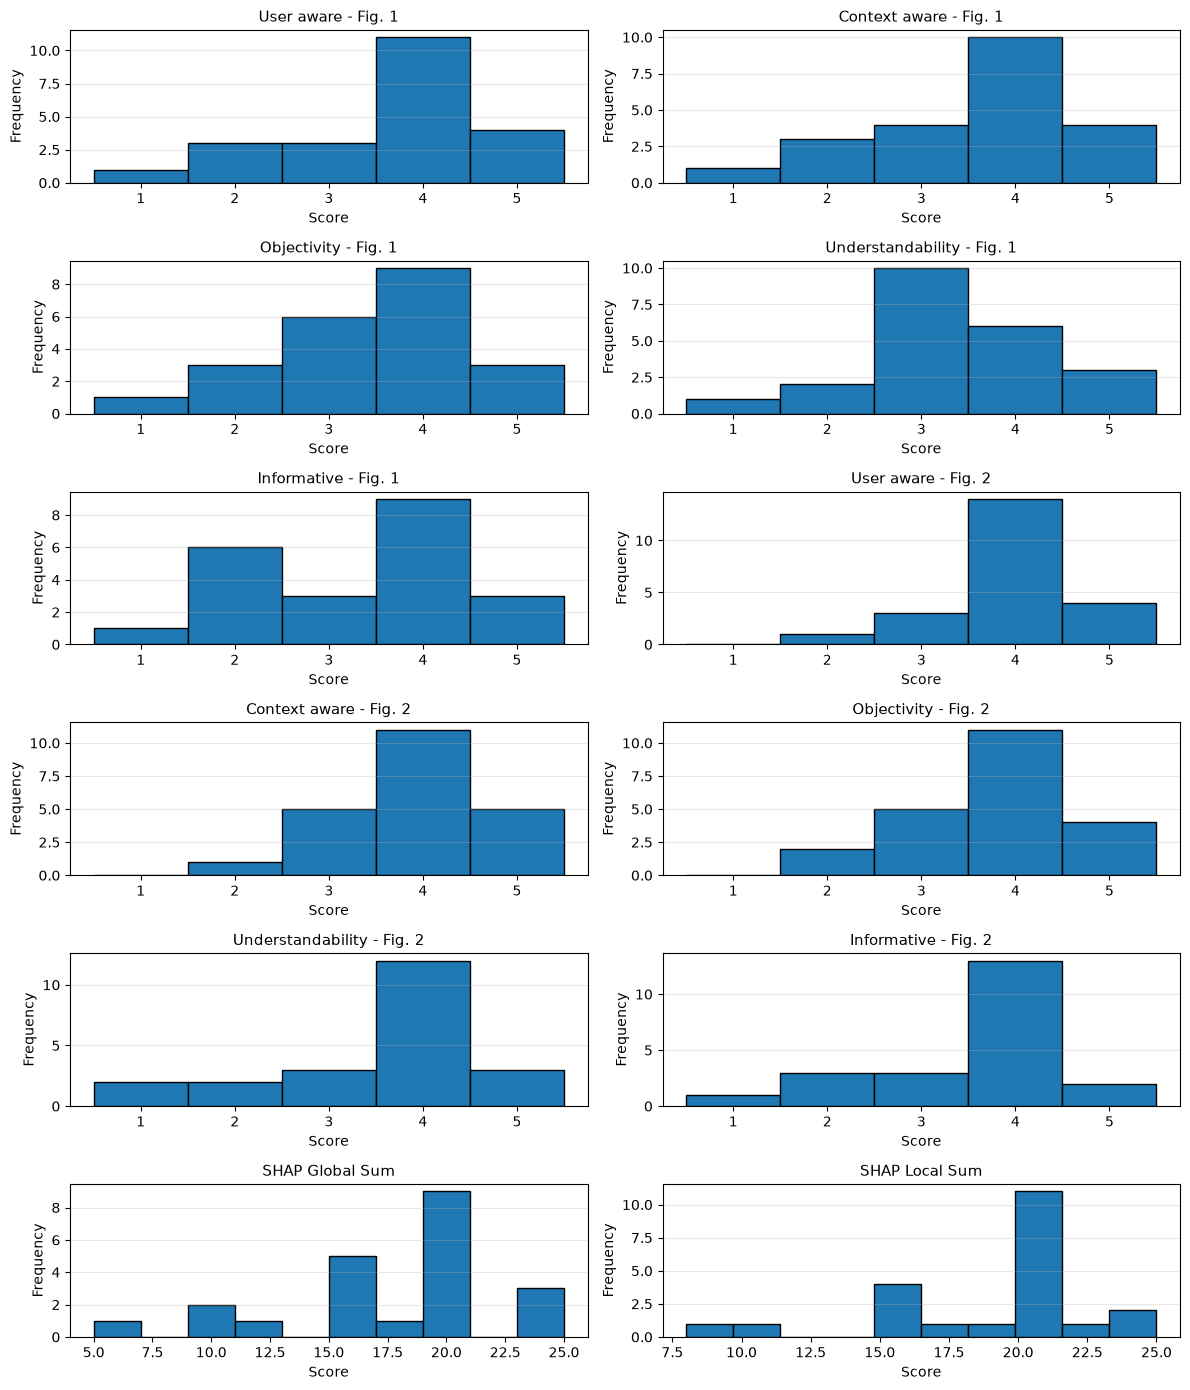

In [4]:
research_questions = [
    "user-aware-fig1",
    "context-aware-fig1",
    "objectivity-fig1",
    "understandability-fig1",
    "informative-fig1",
    "user-aware-fig2",
    "context-aware-fig2",
    "objectivity-fig2",
    "understandability-fig2",
    "informative-fig2",
]

# Converte a estrutura da lista de usuários em DataFrame
rows = []
for user in data:
    row = {"_id": user.get("_id", {}).get("$oid", None)}

    research_answers = {r["questionId"]: r["answer"] for r in user.get("research", [])}
    for q in research_questions:
        row[q] = pd.to_numeric(research_answers.get(q), errors="coerce")

    row["shapLocalSum"] = pd.to_numeric(user.get("shapLocalSum"), errors="coerce")
    row["shapGlobalSum"] = pd.to_numeric(user.get("shapGlobalSum"), errors="coerce")

    rows.append(row)

df = pd.DataFrame(rows)

titles = {
    "user-aware-fig1": "User aware - Fig. 1",
    "context-aware-fig1": "Context aware - Fig. 1",
    "objectivity-fig1": "Objectivity - Fig. 1",
    "understandability-fig1": "Understandability - Fig. 1",
    "informative-fig1": "Informative - Fig. 1",
    "user-aware-fig2": "User aware - Fig. 2",
    "context-aware-fig2": "Context aware - Fig. 2",
    "objectivity-fig2": "Objectivity - Fig. 2",
    "understandability-fig2": "Understandability - Fig. 2",
    "informative-fig2": "Informative - Fig. 2",
    "shapLocalSum": "SHAP Local Sum",
    "shapGlobalSum": "SHAP Global Sum",
}

columns = research_questions + ["shapGlobalSum", "shapLocalSum"]

fig, axes = plt.subplots(6, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]
    values = df[col].dropna()

    if col in research_questions:
        ax.hist(values, bins=np.arange(0.5, 6.5, 1), edgecolor="black")
        ax.set_xticks([1, 2, 3, 4, 5])
    else:
        ax.hist(values, bins=10, edgecolor="black")

    ax.set_title(titles[col], fontsize=11)
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def descriptive_stats(values):
    import pandas as pd
    s = pd.Series(values, dtype="float")
    modes = s.mode().tolist()
    return {
        "n": int(s.count()),
        "média": s.mean(),
        "mediana": s.median(),
        "desvio_padrão": s.std(ddof=1),
        "mín": s.min(),
        "máx": s.max(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "moda": modes[0] if modes else None,
    }

# Perguntas do research para figura 1
research_fig1_data = pd.DataFrame({
    "user-aware": [int(item["answer"]) for user in data for item in user["research"] if "user-aware-fig1" in item["questionId"]],
    "context-aware": [int(item["answer"]) for user in data for item in user["research"] if "context-aware-fig1" in item["questionId"]],
    "objectivity": [int(item["answer"]) for user in data for item in user["research"] if "objectivity-fig1" in item["questionId"]],
    "understandability": [int(item["answer"]) for user in data for item in user["research"] if "understandability-fig1" in item["questionId"]],
    "informative": [int(item["answer"]) for user in data for item in user["research"] if "informative-fig1" in item["questionId"]],
})
research_fig1_data["shapGlobalSum"] = research_fig1_data.sum(axis=1)

# Perguntas do research para figura 2
research_fig2_data = pd.DataFrame({
    "user-aware": [int(item["answer"]) for user in data for item in user["research"] if "user-aware-fig2" in item["questionId"]],
    "context-aware": [int(item["answer"]) for user in data for item in user["research"] if "context-aware-fig2" in item["questionId"]],
    "objectivity": [int(item["answer"]) for user in data for item in user["research"] if "objectivity-fig2" in item["questionId"]],
    "understandability": [int(item["answer"]) for user in data for item in user["research"] if "understandability-fig2" in item["questionId"]],
    "informative": [int(item["answer"]) for user in data for item in user["research"] if "informative-fig2" in item["questionId"]],
})
research_fig2_data["shapLocalSum"] = research_fig2_data.sum(axis=1)

# Calcular estatísticas descritivas para cada pergunta e soma
stats_fig1 = {col: descriptive_stats(research_fig1_data[col]) for col in research_fig1_data.columns}
stats_fig2 = {col: descriptive_stats(research_fig2_data[col]) for col in research_fig2_data.columns}

stats_fig1_df = pd.DataFrame(stats_fig1).T
stats_fig2_df = pd.DataFrame(stats_fig2).T

print("Estatísticas descritivas para Figura 1 (Global):")
print(stats_fig1_df.round(2))

print("\n")

print("Estatísticas descritivas para Figura 2 (Local):")
print(stats_fig2_df.round(2))

Estatísticas descritivas para Figura 1 (Global):
                      n  média  mediana  desvio_padrão  mín   máx  iqr  moda
user-aware         22.0   3.64      4.0           1.09  1.0   5.0  1.0   4.0
context-aware      22.0   3.59      4.0           1.10  1.0   5.0  1.0   4.0
objectivity        22.0   3.45      4.0           1.06  1.0   5.0  1.0   4.0
understandability  22.0   3.36      3.0           1.00  1.0   5.0  1.0   3.0
informative        22.0   3.32      4.0           1.17  1.0   5.0  2.0   4.0
shapGlobalSum      22.0  17.36     19.0           4.96  5.0  25.0  5.0  20.0


Estatísticas descritivas para Figura 2 (Local):
                      n  média  mediana  desvio_padrão  mín   máx   iqr  moda
user-aware         22.0   3.95      4.0           0.72  2.0   5.0  0.00   4.0
context-aware      22.0   3.91      4.0           0.81  2.0   5.0  0.75   4.0
objectivity        22.0   3.77      4.0           0.87  2.0   5.0  1.00   4.0
understandability  22.0   3.55      4.0           

# Correlação entre conhecimento prévio e resposta do questionário

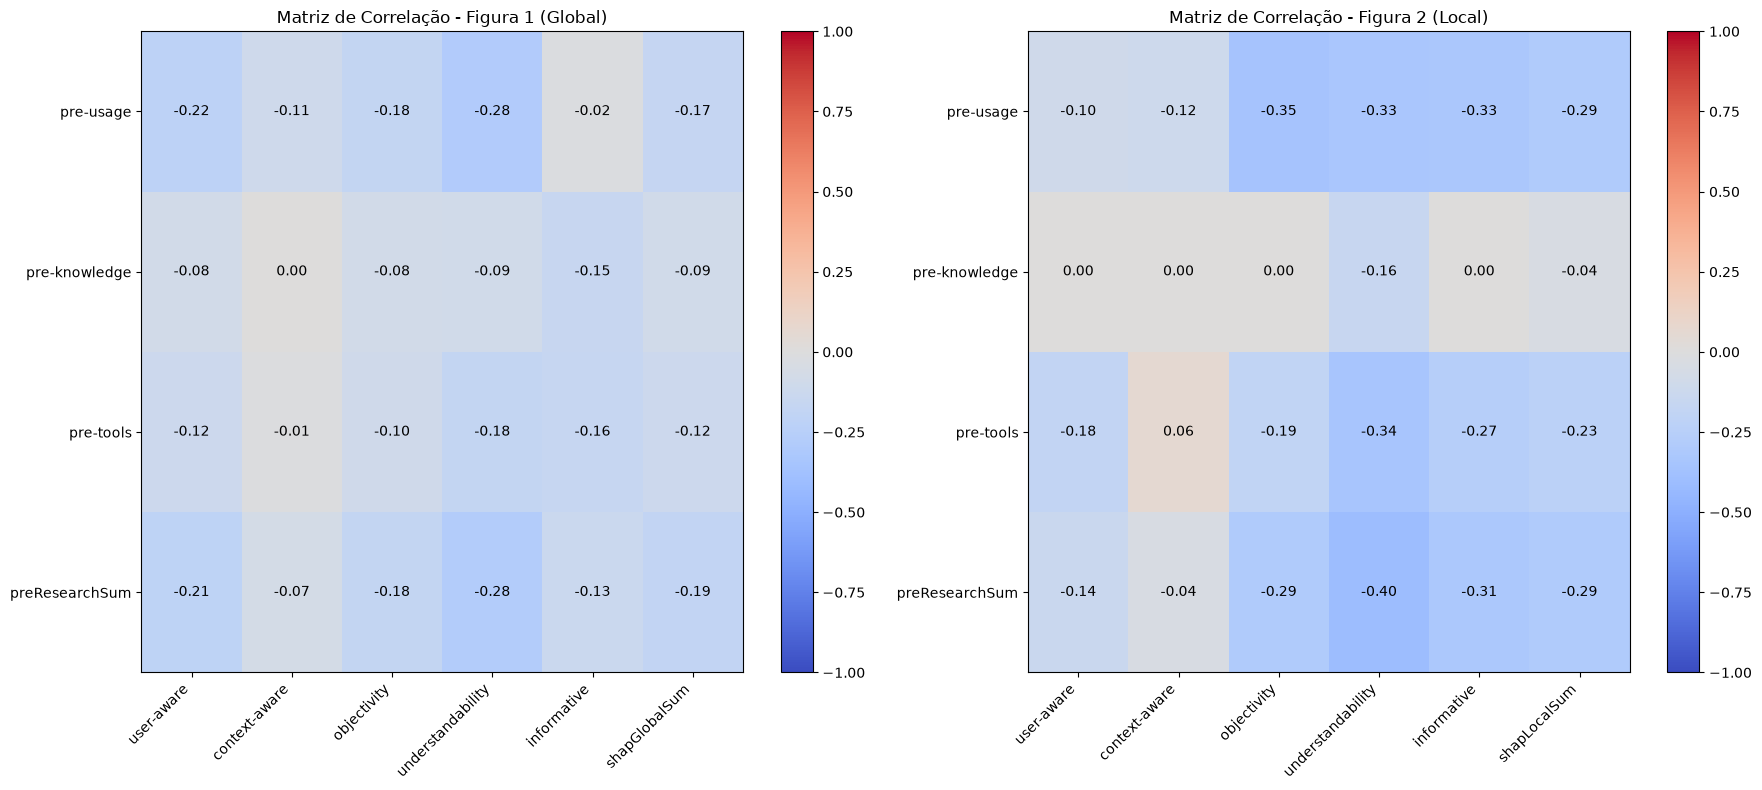

In [6]:
pre_research_with_sum = pre_research_data.copy()
pre_research_with_sum['preResearchSum'] = pre_research_data.sum(axis=1)

research_fig1_with_sum = research_fig1_data.copy()
research_fig1_with_sum['shapGlobalSum'] = research_fig1_data.sum(axis=1)

research_fig2_with_sum = research_fig2_data.copy()
research_fig2_with_sum['shapLocalSum'] = research_fig2_data.sum(axis=1)

pre_research_with_sum = pre_research_with_sum.apply(pd.to_numeric, errors='coerce')
research_fig1_with_sum = research_fig1_with_sum.apply(pd.to_numeric, errors='coerce')
research_fig2_with_sum = research_fig2_with_sum.apply(pd.to_numeric, errors='coerce')

def build_corr_matrix(left_df, right_df):
    corr = pd.DataFrame(index=left_df.columns, columns=right_df.columns, dtype=float)
    for r in left_df.columns:
        for c in right_df.columns:
            corr.loc[r, c] = left_df[r].corr(right_df[c])
    return corr

correlation_4x7_fig1 = build_corr_matrix(pre_research_with_sum, research_fig1_with_sum)
correlation_4x7_fig2 = build_corr_matrix(pre_research_with_sum, research_fig2_with_sum)

pre_cols = pre_research_with_sum.columns.tolist()
fig1_cols = research_fig1_with_sum.columns.tolist()
fig2_cols = research_fig2_with_sum.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Figura 1
im1 = axes[0].imshow(
    correlation_4x7_fig1.values,
    cmap='coolwarm',
    interpolation='none',
    aspect='auto',
    vmin=-1, vmax=1
)
axes[0].set_title('Matriz de Correlação - Figura 1 (Global)')
axes[0].set_xticks(np.arange(len(fig1_cols)))
axes[0].set_yticks(np.arange(len(pre_cols)))
axes[0].set_xticklabels(fig1_cols, rotation=45, ha='right')
axes[0].set_yticklabels(pre_cols)

for i, row in enumerate(pre_cols):
    for j, col in enumerate(fig1_cols):
        val = correlation_4x7_fig1.loc[row, col]
        axes[0].text(j, i, 'nan' if pd.isna(val) else f'{val:.2f}',
                     ha='center', va='center', color='black')

fig.colorbar(im1, ax=axes[0], orientation='vertical')

# Figura 2
im2 = axes[1].imshow(
    correlation_4x7_fig2.values,
    cmap='coolwarm',
    interpolation='none',
    aspect='auto',
    vmin=-1, vmax=1
)
axes[1].set_title('Matriz de Correlação - Figura 2 (Local)')
axes[1].set_xticks(np.arange(len(fig2_cols)))
axes[1].set_yticks(np.arange(len(pre_cols)))
axes[1].set_xticklabels(fig2_cols, rotation=45, ha='right')
axes[1].set_yticklabels(pre_cols)

for i, row in enumerate(pre_cols):
    for j, col in enumerate(fig2_cols):
        val = correlation_4x7_fig2.loc[row, col]
        axes[1].text(j, i, 'nan' if pd.isna(val) else f'{val:.2f}',
                     ha='center', va='center', color='black')

fig.colorbar(im2, ax=axes[1], orientation='vertical')

plt.tight_layout()
plt.show()